In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
import time

In [2]:
# Load the latest version
file_path = "./data/dataset.csv"

df = pd.read_csv(file_path)
df = df.drop(columns=["Value"], errors="ignore")

print("First 5 records:\n", df.head())

First 5 records:
              Name     Nationality  Age Overall rating  \
0     J. Manzambi     Switzerland   19             77   
1       S. Baidoo         Austria   21             76   
2     14J. Putupu  American Samoa   37             39   
3  A. Al Khaibari    Saudi Arabia   28             70   
4       C. Varela        Portugal   16             68   

            Team & Contract      Height       Weight   foot Best position  \
0    SC Freiburg2024 ~ 2030  183cm 6'0"  75kg 165lbs  Right           CAM   
1        RC Lens2025 ~ 2030  190cm 6'3"  82kg 181lbs  Right            CB   
2        American SamoaFree  170cm 5'7"  73kg 161lbs  Right            CB   
3       Al Nassr2019 ~ 2029  175cm 5'9"  75kg 165lbs  Right           CDM   
4  Dinamo Zagreb2025 ~ 2028  169cm 5'7"  60kg 132lbs  Right            RM   

    Value  Total attacking  Total skill  Total movement  Total power  \
0  €22.5M              332          339             392          373   
1    €14M              220      

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Name             12000 non-null  str  
 1   Nationality      12000 non-null  str  
 2   Age              12000 non-null  int64
 3   Overall rating   12000 non-null  str  
 4   Team & Contract  12000 non-null  str  
 5   Height           12000 non-null  str  
 6   Weight           12000 non-null  str  
 7   foot             12000 non-null  str  
 8   Best position    12000 non-null  str  
 9   Value            12000 non-null  str  
 10  Total attacking  12000 non-null  int64
 11  Total skill      12000 non-null  int64
 12  Total movement   12000 non-null  int64
 13  Total power      12000 non-null  int64
 14  Total mentality  12000 non-null  int64
 15  Total defending  12000 non-null  int64
 16  Body type        12000 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.6 MB


In [4]:
rows_before_gk_filter = len(df)

df = df.loc[
    df["Best position"].astype("string").str.strip().str.upper().ne("GK")
].copy()

print(f"Removed {rows_before_gk_filter - len(df):,} GK players.")
print(f"Remaining players: {len(df):,}")

Removed 1,251 GK players.
Remaining players: 10,749


In [5]:
import re

df = pd.read_csv(file_path)
df = df.drop(columns=["Value"], errors="ignore")


def normalize_team(series):
    return (
        series.astype("string")
        .str.replace(r"(?:\d{4}.*|[A-Z][a-z]{2} \d{1,2}, \d{4}.*|Free)$", "", regex=True)
        .str.strip()
    )


def normalize_measure(series, unit):
    values = series.astype("string").str.extract(
        rf"(\d+(?:\.\d+)?)\s*{unit}", expand=False
    )
    return pd.to_numeric(values, errors="coerce").astype("Float64")


def normalize_value(series):
    values = series.astype("string").str.extract(
        r"€?\s*(\d+(?:\.\d+)?)\s*([KMB])?", expand=False
    )
    number = pd.to_numeric(values[0], errors="coerce")
    multiplier = values[1].map({"K": 0.001, "M": 1, "B": 1000}).fillna(1)
    return (number * multiplier).astype("Float64")


def normalize_body_type(series):
    return series.astype("string").str.replace(
        r"\s*\([^)]*\)", "", regex=True
    ).str.strip()


# Keep only the requested unit or text portion in each field.
df["Team & Contract"] = normalize_team(df["Team & Contract"])
df["Height"] = normalize_measure(df["Height"], "cm")
df["Weight"] = normalize_measure(df["Weight"], "kg")
df["Body type"] = normalize_body_type(df["Body type"])


output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(
    f"Saved {len(df):,} rows to {output_path}"
)
df[["Team & Contract", "Height", "Weight", "Body type"]].head()

Removed 190 rows with Value == 0. Saved 11,810 rows to ./data/dataset_cleaned.csv


,Team & Contract,Height,Weight,Value,Body type
0,SC Freiburg,183.0,75.0,22.5,Normal
1,RC Lens,190.0,82.0,14.0,Normal
3,Al Nassr,175.0,75.0,1.4,Lean
4,Dinamo Zagreb,169.0,60.0,3.3,Lean
5,Real Madrid,186.0,75.0,150.5,Normal


In [6]:
# Add a unique row identifier and classify every column.
if "ID" in df.columns:
    df = df.drop(columns="ID")
df.insert(0, "ID", range(1, len(df) + 1))

numeric_columns = [
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]
categorical_columns = [
    "Name",
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
]

column_types = pd.DataFrame({"Column": df.columns})
column_types["Type"] = column_types["Column"].map(
    lambda column: "Key" if column == "ID"
    else "Numeric" if column in numeric_columns
    else "Categorical" if column in categorical_columns
    else "Unknown"
)

if column_types["Type"].eq("Unknown").any():
    raise ValueError(
        f"Unclassified columns: {column_types.loc[column_types['Type'].eq('Unknown'), 'Column'].tolist()}"
    )

output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Added unique ID for {len(df):,} rows")
print(f"Saved classified dataset to {output_path}")
column_types

Added unique ID for 11,810 rows
Saved classified dataset to ./data/dataset_cleaned.csv


,Column,Type
0,ID,Key
1,Name,Categorical
2,Nationality,Categorical
3,Age,Numeric
4,Overall rating,Numeric
5,Team & Contract,Categorical
6,Height,Numeric
7,Weight,Numeric
8,foot,Categorical
9,Best position,Categorical


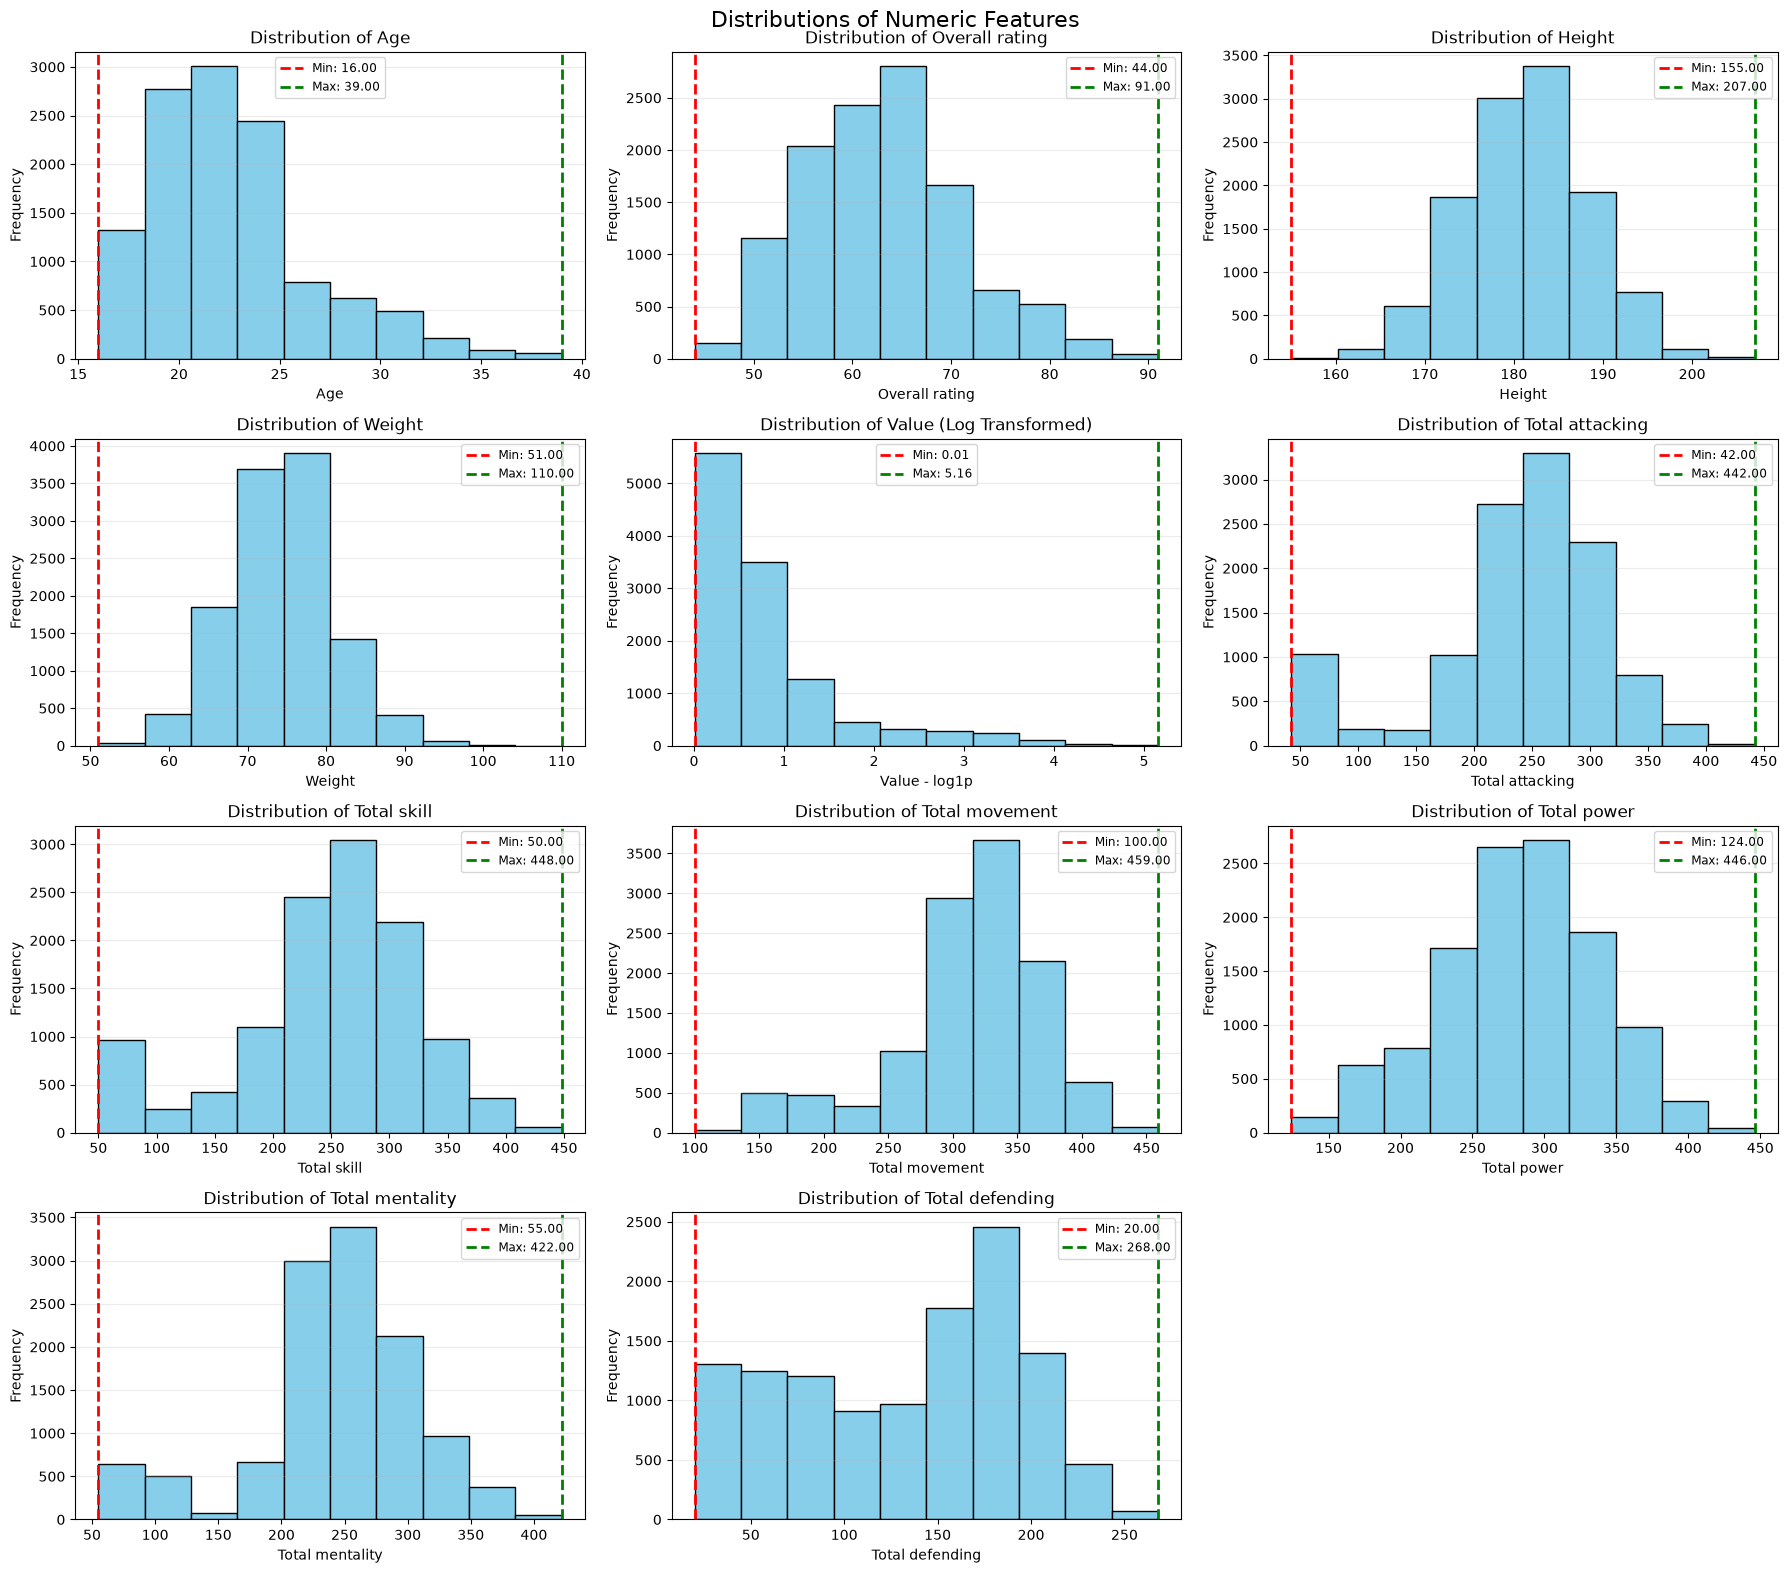

In [7]:
# Plot numeric distributions, using log transformation for skewed features.
numeric_data = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
log_transformed_columns = set()
numeric_data[list(log_transformed_columns)] = np.log1p(
    numeric_data[list(log_transformed_columns)]
)

number_of_columns = 3
number_of_rows = int(np.ceil(len(numeric_columns) / number_of_columns))
fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 4 * number_of_rows),
)
axes = np.asarray(axes).reshape(-1)

for axis, column in zip(axes, numeric_columns):
    col_data = numeric_data[column].dropna()
    
    # Vẽ biểu đồ Histogram
    axis.hist(
        col_data,
        bins=10,
        color="skyblue",
        edgecolor="black",
    )
    
    # Đánh dấu (highlight) Min và Max
    if not col_data.empty:
        min_val = col_data.min()
        max_val = col_data.max()
        axis.axvline(min_val, color="red", linestyle="dashed", linewidth=2, label=f"Min: {min_val:.2f}")
        axis.axvline(max_val, color="green", linestyle="dashed", linewidth=2, label=f"Max: {max_val:.2f}")
        axis.legend(fontsize="small", loc="best")
    
    axis_title = f"Distribution of {column}"
    axis_label = column
    if column in log_transformed_columns:
        axis_title += " (Log Transformed)"
        axis_label += " - log1p"
    axis.set_title(axis_title)
    axis.set_xlabel(axis_label)
    axis.set_ylabel("Frequency")
    axis.grid(axis="y", alpha=0.25)

for axis in axes[len(numeric_columns):]:
    axis.set_visible(False)

fig.suptitle("Distributions of Numeric Features", fontsize=16)
fig.tight_layout()
plt.show()


In [9]:
# Create a separate CSV with prefixed categorical values and tokenized numeric values.
categorical_prefixes = {
    "Nationality": "Na",
    "Team & Contract": "Tc",
    "foot": "F",
    "Best position": "Bp",
    "Body type": "Bt",
}
numeric_prefixes = {
    "Age": "a",
    "Overall rating": "o",
    "Height": "h",
    "Weight": "w",
    "Total attacking": "ta",
    "Total skill": "ts",
    "Total movement": "tm",
    "Total power": "tp",
    "Total mentality": "tme",
    "Total defending": "td",
}

tokenized_df = df[["ID", *categorical_columns]].copy()

for column, prefix in categorical_prefixes.items():
    tokenized_df[column] = (
        tokenized_df[column]
        .astype("string")
        .map(lambda value: f"{prefix}_{value}" if pd.notna(value) else "NA")
    )

for column, prefix in numeric_prefixes.items():
    values = pd.to_numeric(df[column], errors="coerce")
    bin_numbers = pd.qcut(
        values,
        q=5,
        labels=False,
        duplicates="drop",
    )
    tokenized_df[column] = (
        bin_numbers.add(1)
        .astype("Int64")
        .astype("string")
        .radd(prefix)
        .fillna("NA")
    )

tokenized_output_path = "./data/dataset_tokenized.csv"
tokenized_df.to_csv(
    tokenized_output_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved {len(tokenized_df):,} tokenized rows to {tokenized_output_path}")
tokenized_df.head()

Saved 11,810 tokenized rows to ./data/dataset_tokenized.csv


,ID,Name,Nationality,Team & Contract,foot,Best position,Body type,Age,Overall rating,Height,Weight,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending
0,1,J. Manzambi,Na_Switzerland,Tc_SC Freiburg,F_Right,Bp_CAM,Bt_Normal,a1,o5,h3,w3,v5,ta5,ts5,tm5,tp5,tme5,td5
1,2,S. Baidoo,Na_Austria,Tc_RC Lens,F_Right,Bp_CB,Bt_Normal,a2,o5,h5,w5,v5,ta2,ts3,tm3,tp3,tme4,td5
3,3,A. Al Khaibari,Na_Saudi Arabia,Tc_Al Nassr,F_Right,Bp_CDM,Bt_Lean,a5,o5,h1,w3,v4,ta3,ts4,tm4,tp4,tme4,td5
4,4,C. Varela,Na_Portugal,Tc_Dinamo Zagreb,F_Right,Bp_RM,Bt_Lean,a1,o4,h1,w1,v5,ta4,ts5,tm4,tp3,tme3,td1
5,5,J. Bellingham,Na_England,Tc_Real Madrid,F_Right,Bp_CAM,Bt_Normal,a3,o5,h4,w3,v5,ta5,ts5,tm5,tp5,tme5,td5


In [10]:
# Create a bag of tokens for each player.
# ID and Name are kept as identifiers but excluded from training.

training_columns = [
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]

player_bags = tokenized_df[training_columns].apply(
    lambda row: list(row.dropna()),
    axis=1,
)

print(player_bags.iloc[0])

['Na_Switzerland', 'Tc_SC Freiburg', 'F_Right', 'Bp_CAM', 'Bt_Normal', 'a1', 'o5', 'h3', 'w3', 'v5', 'ta5', 'ts5', 'tm5', 'tp5', 'tme5', 'td5']


In [11]:
from collections import Counter

token_counter = Counter()

for bag in player_bags:
    token_counter.update(bag)

vocabulary = sorted(token_counter.keys())

token_to_id = {
    token: index
    for index, token in enumerate(vocabulary)
}

id_to_token = {
    index: token
    for token, index in token_to_id.items()
}

print(f"Vocabulary size: {len(vocabulary):,}")

Vocabulary size: 1,189


In [12]:
for token, token_id in list(token_to_id.items())[:20]:
    print(f"{token:<30} → {token_id}")

Bp_CAM                         → 0
Bp_CB                          → 1
Bp_CDM                         → 2
Bp_CF                          → 3
Bp_CM                          → 4
Bp_GK                          → 5
Bp_LB                          → 6
Bp_LM                          → 7
Bp_LW                          → 8
Bp_LWB                         → 9
Bp_RB                          → 10
Bp_RM                          → 11
Bp_RW                          → 12
Bp_RWB                         → 13
Bp_ST                          → 14
Bt_Lean                        → 15
Bt_Normal                      → 16
Bt_Stocky                      → 17
Bt_Unique                      → 18
F_Left                         → 19


In [13]:
encoded_player_bags = player_bags.apply(
    lambda bag: [
        token_to_id[token]
        for token in bag
    ]
)

print(encoded_player_bags.iloc[0])

[167, 905, 20, 0, 16, 1134, 1148, 1141, 1186, 1183, 1153, 1178, 1163, 1173, 1168, 1158]


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Represent each player using Bag of Words (BoW).
# Instead of training embeddings, each player is represented by a vector of token counts.
vocab_size = len(vocabulary)

def bag_to_vector(bag, vocab_size):
    vec = np.zeros(vocab_size)
    for token_id in bag:
        vec[token_id] += 1
    return vec

player_embeddings = np.array([bag_to_vector(bag, vocab_size) for bag in encoded_player_bags])

def find_similar_players(player_id, top_n=10):
    matching_rows = df.index[df["ID"].eq(player_id)].tolist()
    if not matching_rows:
        raise ValueError(f"Player ID {player_id} was not found.")

    player_index = matching_rows[0]
    similarity_scores = cosine_similarity(
        player_embeddings[player_index:player_index + 1],
        player_embeddings,
    ).ravel()
    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = [
        index for index in similar_indices if index != player_index
    ][:top_n]

    # Return the complete non-tokenized player records with the similarity score.
    result = df.iloc[similar_indices].copy()
    result.insert(1, "Similarity", similarity_scores[similar_indices])
    return result.reset_index(drop=True)


query_id = int(df.iloc[0]["ID"])
print(f"Similar players for ID {query_id}:")
find_similar_players(query_id, top_n=10)

In [60]:
import json
import sqlite3

# Store player embeddings in SQLite for SQL-based similarity queries.
database_path = "./data/player_embeddings.db"
connection = sqlite3.connect(database_path)

# 1. Tạo bản sao của DataFrame và thêm cột 'embedding' vào
df_db = df.copy()
df_db["embedding"] = [json.dumps(emb.tolist()) for emb in player_embeddings]

# 2. Lưu toàn bộ DataFrame trực tiếp vào SQLite (sẽ tự động tạo bảng với tất cả các cột)
df_db.to_sql("player_embeddings", connection, if_exists="replace", index=False)

def cosine_from_json(left_json, right_json):
    left = np.asarray(json.loads(left_json), dtype=float)
    right = np.asarray(json.loads(right_json), dtype=float)
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    return float(np.dot(left, right) / denominator) if denominator else 0.0

connection.create_function("cosine_similarity", 2, cosine_from_json)

query_id = int(df.iloc[0]["ID"])
target_embedding = json.dumps(player_embeddings[0].tolist())

# 3. Thay vì SELECT từng cột, ta có thể SELECT * để lấy toàn bộ thông tin
similarity_result = pd.read_sql_query(
    """
    SELECT *,
           cosine_similarity(embedding, ?) AS Similarity
    FROM player_embeddings
    WHERE ID <> ?
    ORDER BY Similarity DESC
    LIMIT 10
    """,
    connection,
    params=(target_embedding, query_id),
)

# Xóa cột embedding khi in ra để bảng kết quả dễ nhìn hơn
query_result = similarity_result.drop(columns=["embedding"])

# Tuỳ chọn: Đẩy 2 cột ID và Similarity lên đầu bảng, các cột còn lại ở sau
cols = ["ID", "Similarity"] + [c for c in query_result.columns if c not in ["ID", "Similarity"]]
query_result = query_result[cols]

print(f"Saved {len(df_db):,} embeddings with full player info to {database_path}")
query_result


Saved 11,810 embeddings with full player info to ./data/player_embeddings.db


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,348,0.8125,Martim Fernandes,Portugal,19,76,FC Porto,181.0,73.0,Right,RB,15.5,300,327,382,345,334,221,Normal
1,5,0.7500,J. Bellingham,England,22,89,Real Madrid,186.0,75.0,Right,CAM,150.5,396,411,418,431,416,239,Normal
2,18,0.7500,Y. Diomande,Côte d'Ivoire,18,81,RB Leipzig,181.0,76.0,Right,CAM,54.5,362,365,427,362,295,121,Normal
3,205,0.7500,D. Szoboszlai,Hungary,24,86,Liverpool,186.0,74.0,Right,CAM,88.0,396,431,395,414,402,220,Normal
4,370,0.7500,L. Bergvall,Sweden,19,78,Tottenham Hotspur,187.0,74.0,Right,CM,30.0,321,376,373,360,360,217,Normal
5,435,0.7500,O. Pohlmann,Germany,24,71,Rio Ave FC,183.0,73.0,Right,CAM,2.8,317,355,365,359,321,166,Normal
6,494,0.7500,Q. Timber,Netherlands,24,80,Olympique de Marseille,179.0,74.0,Right,CAM,31.5,354,368,400,419,374,220,Normal
7,556,0.7500,D. Frattesi,Italy,25,81,Inter,178.0,74.0,Right,CAM,32.0,371,377,400,385,384,219,Normal
8,637,0.7500,F. Kessié,Côte d'Ivoire,28,79,Al Ahli SFC,183.0,74.0,Right,CDM,15.5,351,343,367,427,393,232,Normal
9,715,0.7500,C. Yirenkyi,Ghana,19,71,FC Nordsjælland,181.0,78.0,Right,CDM,4.4,311,315,377,371,328,210,Normal


In [64]:
from IPython.display import display

def calculate_evaluation_score(query_id, similar_df):
    # Lấy thông tin cầu thủ query từ dataframe gốc
    query_row = df.loc[df['ID'] == query_id].iloc[0]
    
    cat_features = ["Nationality", "Team & Contract", "foot", "Best position", "Body type"]
    num_features = [
        "Age", "Overall rating", "Height", "Weight", 
        "Total attacking", "Total skill", "Total movement", 
        "Total power", "Total mentality", "Total defending"
    ]
    
    scores = []
    for _, candidate_row in similar_df.iterrows():
        S = 0.0
        
        # 1. Tính điểm cho Categorical features
        for col in cat_features:
            if str(query_row[col]) == str(candidate_row[col]):
                S += 1.0
                
        # 2. Tính điểm cho Numeric features
        for col in num_features:
            try:
                q_val = float(query_row[col])
                c_val = float(candidate_row[col])
                
                # Xử lý trường hợp cả 2 đều bằng 0
                if q_val == 0 and c_val == 0:
                    S += 1.0
                elif max(q_val, c_val) != 0:
                    S += min(q_val, c_val) / max(q_val, c_val)
            except (ValueError, TypeError):
                pass # Bỏ qua nếu dữ liệu lỗi
        scores.append(S)
        
    # Tạo bản sao của dataframe kết quả để thêm cột điểm
    result_df = similar_df.copy()
    
    # Số lượng features
    total_features = len(cat_features) + len(num_features)
    
    # Chèn thêm cột Độ chính xác (%)
    accuracies = [s / total_features for s in scores]
    result_df.insert(2, 'Accuracy (%)', accuracies)
    
    # SẮP XẾP DF TẠI ĐÂY
    # Lưu ý: Đảm bảo cột tính khoảng cách từ find_similar_players có tên chính xác là 'Similarity'
    result_df = result_df.sort_values(by=['Similarity', 'Accuracy (%)'], ascending=[False, False])
    
    return result_df

# Thử nghiệm hàm đánh giá với query_id = 17
query_id = 17
player_info = df.loc[df["ID"] == query_id]
similar_players = find_similar_players(query_id, top_n=50)
evaluated_results = calculate_evaluation_score(query_id, similar_players)

print(f"Kết quả đánh giá độ tương đồng cho cầu thủ ID {query_id}:")
display(player_info)
display(evaluated_results)

Kết quả đánh giá độ tương đồng cho cầu thủ ID 17:


,ID,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
18,17,K. Mbappé,France,26,91,Real Madrid,182.0,81.0,Right,ST,157.0,424,408,459,427,357,92,Unique


,ID,Similarity,Accuracy (%),Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
16,300,0.7500,0.778862,R. Lewandowski,Poland,36,86,FC Barcelona,186.0,81.0,Right,ST,23.0,422,397,384,417,384,96,Unique
0,2176,0.7500,0.773655,K. Benzema,France,37,85,Al Hilal,185.0,81.0,Right,ST,18.5,420,401,383,407,341,85,Normal
18,1538,0.7500,0.763371,R. Kolo Muani,France,26,79,Tottenham Hotspur,187.0,73.0,Right,ST,21.0,375,352,412,386,300,97,Lean
2,607,0.7500,0.724194,S. Guirassy,Guinea,29,85,Borussia Dortmund,187.0,82.0,Right,ST,54.0,400,380,381,429,356,122,Normal
4,1832,0.7500,0.724194,S. Guirassy,Guinea,29,85,Borussia Dortmund,187.0,82.0,Right,ST,54.0,400,380,381,429,356,122,Normal
8,408,0.7500,0.702247,N. Jackson,Senegal,24,79,FC Bayern München,187.0,82.0,Right,ST,24.5,372,344,386,396,328,100,Lean
17,245,0.7500,0.697024,D. Núñez,Uruguay,26,78,Al Hilal,187.0,81.0,Right,ST,18.5,368,355,383,413,367,133,Lean
7,7661,0.7500,0.688589,Clayton,Brazil,26,76,Olympiacos FC,184.0,88.0,Right,ST,9.0,359,321,365,395,327,87,Normal
19,1647,0.7500,0.687980,L. Nmecha,Germany,26,76,Leeds United,185.0,80.0,Right,ST,9.0,355,317,367,386,333,103,Stocky
3,1264,0.7500,0.666047,T. Lemperle,Germany,23,76,TSG,187.0,78.0,Right,ST,11.0,352,311,363,375,300,111,Lean
